<>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\USER\AppData\Local\Temp\ipykernel_8860\2709386568.py:33: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.ylabel('Probability \sigma(z)')


TASK-1 

Computed z-value for student: 2.5000
Computed probability (sigmoid): 0.9241
Sigmoid value when z = 0: 0.5


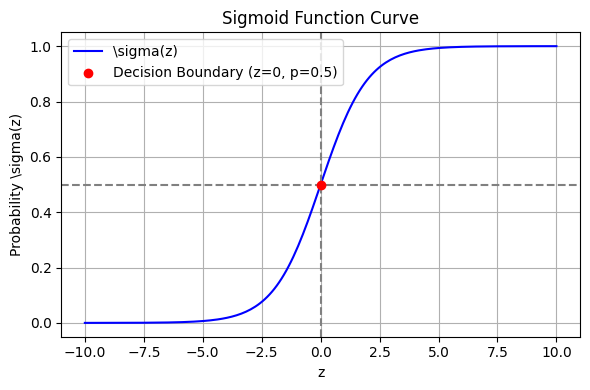

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

w = np.array([1.2, -0.8])
b = 0.3
print("TASK-1 \n")
study_hours = 1.5
sleep_hours = -0.5
x = np.array([study_hours, sleep_hours])

z_student = np.dot(w, x) + b
prob_student = sigmoid(z_student)

print(f"Computed z-value for student: {z_student:.4f}")
print(f"Computed probability (sigmoid): {prob_student:.4f}")

z_zero = 0.0
print(f"Sigmoid value when z = 0: {sigmoid(z_zero)}")

z_range = np.linspace(-10, 10, 200)
sigma_values = sigmoid(z_range)

plt.figure(figsize=(6, 4))
plt.plot(z_range, sigma_values, color='blue', label=r'\sigma(z)')
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0.5, color='gray', linestyle='--')
plt.scatter(0, 0.5, color='red', zorder=5, label='Decision Boundary (z=0, p=0.5)')

plt.xlabel('z')
plt.ylabel('Probability \sigma(z)')
plt.title('Sigmoid Function Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('sigmoid_curve.png')
plt.show()

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

print("TASK-2\n")
df = pd.read_csv("students_feature_engineered_v2.csv")
X = df.drop(columns=["Pass"])
y = df["Pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

pipe_base = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=1.0, max_iter=1000, random_state=42))
])
pipe_base.fit(X_train, y_train)

train_preds = pipe_base.predict(X_train)
test_preds = pipe_base.predict(X_test)
train_probas = pipe_base.predict_proba(X_train)

train_acc = accuracy_score(y_train, train_preds)
test_acc = accuracy_score(y_test, test_preds)
train_loss = log_loss(y_train, train_probas)

print("Baseline Model")
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy:  {test_acc:.3f}")
print(f"Train Log Loss: {train_loss:.3f}\n")

for c_val in [100, 0.01]:
    pipe_sweep = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=c_val, max_iter=1000, random_state=42))
    ])
    pipe_sweep.fit(X_train, y_train)
    sweep_test_acc = accuracy_score(y_test, pipe_sweep.predict(X_test))
    print(f"Model with C = {c_val:6.2f}, Test Accuracy: {sweep_test_acc:.3f}")

TASK-2

Baseline Model
Train Accuracy: 1.000
Test Accuracy:  1.000
Train Log Loss: 0.003

Model with C = 100.00, Test Accuracy: 1.000
Model with C =   0.01, Test Accuracy: 1.000


In [4]:
coefficients = pipe_base.named_steps['clf'].coef_[0]
intercept = pipe_base.named_steps['clf'].intercept_[0]
feature_names = X.columns

print("TASK-3 \n")

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
})

coef_df = coef_df.sort_values(by='coefficient', ascending=False).reset_index(drop=True)
print(f"Model Intercept (Constant): {intercept:.4f}\n")
print(coef_df.to_string(index=False))

TASK-3 

Model Intercept (Constant): 3.3171

          feature  coefficient  odds_ratio
        City_Pune     0.154466    1.167035
        Height_cm    -0.357468    0.699445
Days_Since_Enroll    -1.127776    0.323753
      City_Mumbai    -1.604441    0.201002
        Weight_kg    -1.858810    0.155858
              BMI    -2.439567    0.087199


In [7]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
print("TASK-4 \n")
print(f"Confusion Matrix Elements:\nTN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}\n")
manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)

print("Metric Function Verification")
print(f"Precision, Manual: {manual_precision:.3f},  Sklearn: {precision_score(y_test, test_preds):.3f}")
print(f"Recall,    Manual: {manual_recall:.3f},  Sklearn: {recall_score(y_test, test_preds):.3f}")
print(f"F1-Score,  Manual: {manual_f1:.3f},  Sklearn: {f1_score(y_test, test_preds):.3f}\n")

test_df = X_test.copy()
test_df['Actual'] = y_test
test_df['Predicted'] = test_preds

fn_cases = test_df[(test_df['Actual'] == 1) & (test_df['Predicted'] == 0)]

if len(fn_cases) > 0:
    first_fn = fn_cases.iloc[0]
    print("Example False Negative Case Profile")
    print(first_fn.drop(['Actual', 'Predicted']))
else:
    print("No False Negatives found")

TASK-4 

Confusion Matrix Elements:
TN: 68, FP: 0, FN: 0, TP: 132

Metric Function Verification
Precision, Manual: 1.000,  Sklearn: 1.000
Recall,    Manual: 1.000,  Sklearn: 1.000
F1-Score,  Manual: 1.000,  Sklearn: 1.000

No False Negatives found


TASK-5 



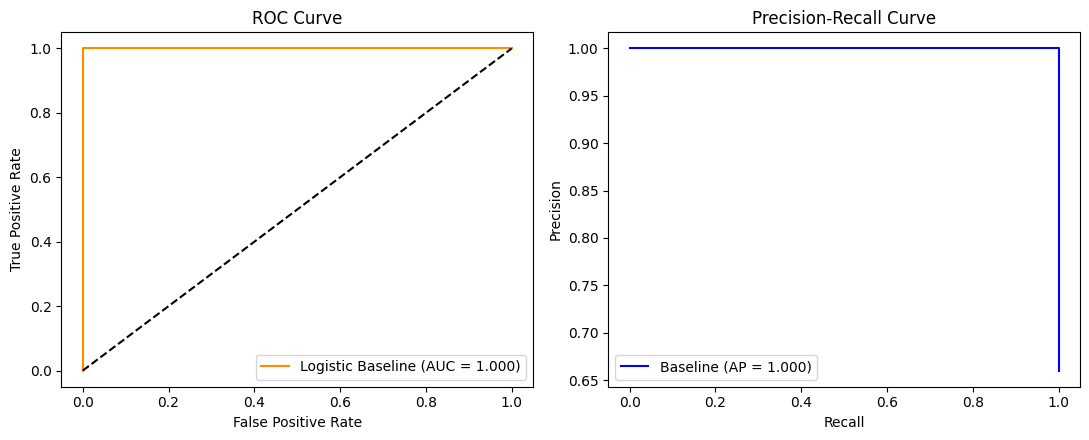

Imbalanced Subsampling Metric Comparison 
Original Balanced Test   ,AUC: 1.000 , AP: 1.000
Imbalanced Test (15% Y)  ,AUC: 1.000  , AP: 1.000


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

test_probas = pipe_base.predict_proba(X_test)[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
print("TASK-5 \n")
fpr, tpr, _ = roc_curve(y_test, test_probas)
base_auc = roc_auc_score(y_test, test_probas)
ax1.plot(fpr, tpr, label=f'Logistic Baseline (AUC = {base_auc:.3f})', color='darkorange')
ax1.plot([0, 1], [0, 1], 'k--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend()

precision, recall, _ = precision_recall_curve(y_test, test_probas)
base_ap = average_precision_score(y_test, test_probas)
ax2.plot(recall, precision, label=f'Baseline (AP = {base_ap:.3f})', color='blue')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
plt.tight_layout()
plt.show()

def downsample_positive_class(X_data, y_data, target_positive_rate=0.15, random_state=42):
    rng = np.random.RandomState(random_state)
    pos_idx = np.where(y_data == 1)[0]
    neg_idx = np.where(y_data == 0)[0]
    n_pos_keep = int(len(neg_idx) * target_positive_rate / (1 - target_positive_rate))
    keep_pos = rng.choice(pos_idx, size=min(n_pos_keep, len(pos_idx)), replace=False)
    keep_idx = np.concatenate([neg_idx, keep_pos])
    rng.shuffle(keep_idx)
    return X_data.iloc[keep_idx], y_data.iloc[keep_idx]

X_test_imb, y_test_imb = downsample_positive_class(X_test, y_test, target_positive_rate=0.15, random_state=42)
imb_probas = pipe_base.predict_proba(X_test_imb)[:, 1]

imb_auc = roc_auc_score(y_test_imb, imb_probas)
imb_ap = average_precision_score(y_test_imb, imb_probas)

print("Imbalanced Subsampling Metric Comparison ")
print(f"Original Balanced Test   ,AUC: {base_auc:.3f} , AP: {base_ap:.3f}")
print(f"Imbalanced Test (15% Y)  ,AUC: {imb_auc:.3f}  , AP: {imb_ap:.3f}")

In [13]:
from sklearn.model_selection import cross_val_predict

train_cv_probas = cross_val_predict(pipe_base, X_train, y_train, cv=5, method="predict_proba")[:, 1]
print("TASK-6\n")
fail_cv_probas = 1.0 - train_cv_probas
y_train_fail = (y_train == 0).astype(int)

thresholds = np.arange(0.05, 0.96, 0.01)
best_threshold = 0.5
associated_precision = 0.0

for thr in thresholds:
    preds_fail = (fail_cv_probas >= thr).astype(int)

    tp_f = np.sum((preds_fail == 1) & (y_train_fail == 1))
    fn_f = np.sum((preds_fail == 0) & (y_train_fail == 1))
    fp_f = np.sum((preds_fail == 1) & (y_train_fail == 0))
    
    rec_f = tp_f / (tp_f + fn_f) if (tp_f + fn_f) > 0 else 0
    prec_f = tp_f / (tp_f + fp_f) if (tp_f + fp_f) > 0 else 0
    
    if rec_f >= 0.95:
        best_threshold = thr
        associated_precision = prec_f

print(f"Tuned Optimal Threshold for Fail class: {best_threshold:.2f}")
print(f"Associated CV Precision at this setting: {associated_precision:.3f}\n")

test_fail_probas = 1.0 - test_probas
y_test_fail = (y_test == 0).astype(int)
tuned_test_preds_fail = (test_fail_probas >= best_threshold).astype(int)

tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test_fail, tuned_test_preds_fail).ravel()
test_precision_fail = tp_t / (tp_t + fp_t)
test_recall_fail = tp_t / (tp_t + fn_t)

print("Final Tuned Test Metrics (Fail Class)")
print(f"Confusion Matrix:\n[[{tn_t}, {fp_t}],\n [{fn_t}, {tp_t}]]")
print(f"Tuned Test Precision: {test_precision_fail:.3f}")
print(f"Tuned Test Recall:    {test_recall_fail:.3f}")

TASK-6

Tuned Optimal Threshold for Fail class: 0.95
Associated CV Precision at this setting: 1.000

Final Tuned Test Metrics (Fail Class)
Confusion Matrix:
[[132, 0],
 [0, 68]]
Tuned Test Precision: 1.000
Tuned Test Recall:    1.000


In [12]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score, f1_score
print("TASK-7\n")
param_grid = {
    'clf__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'clf__penalty': ['l2'] 
}

grid = GridSearchCV(pipe_base, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best Hyperparameters: {grid.best_params_}")
print(f"Best CV AUC Score:    {grid.best_score_:.3f}\n")

best_log_reg = grid.best_estimator_

models = {
    'Logistic Regression': best_log_reg,
    'Decision Tree (d=3)': Pipeline([('sc', StandardScaler()), ('clf', DecisionTreeClassifier(max_depth=3, random_state=42))]),
    'Random Forest': Pipeline([('sc', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'KNN (k=7)': Pipeline([('sc', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=7, metric='manhattan'))])
}

comparison_rows = []

for name, model in models.items():
    if name != 'Logistic Regression':
        model.fit(X_train, y_train)
        
    m_preds = model.predict(X_test)
    m_probas = model.predict_proba(X_test)[:, 1]
    
    comparison_rows.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, m_preds), 3),
        'Precision': round(precision_score(y_test, m_preds), 3),
        'Recall': round(recall_score(y_test, m_preds), 3),
        'F1-Score': round(f1_score(y_test, m_preds), 3),
        'AUC': round(roc_auc_score(y_test, m_probas), 3)
    })

comparison_table = pd.DataFrame(comparison_rows)
print(comparison_table.to_string(index=False))

TASK-7



C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Hyperparameters: {'clf__C': 0.01, 'clf__penalty': 'l2'}
Best CV AUC Score:    1.000

              Model  Accuracy  Precision  Recall  F1-Score  AUC
Logistic Regression       1.0        1.0     1.0       1.0  1.0
Decision Tree (d=3)       1.0        1.0     1.0       1.0  1.0
      Random Forest       1.0        1.0     1.0       1.0  1.0
          KNN (k=7)       1.0        1.0     1.0       1.0  1.0


TASK-8



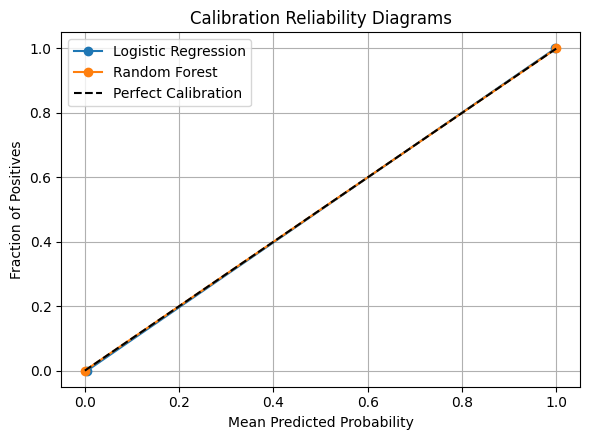

In [14]:
from sklearn.calibration import calibration_curve
print("TASK-8\n")
rf_model = models['Random Forest']
rf_probas = rf_model.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 4.5))
for name, prob in [('Logistic Regression', test_probas), ('Random Forest', rf_probas)]:
    frac_pos, mean_pred = calibration_curve(y_test, prob, n_bins=5)
    plt.plot(mean_pred, frac_pos, marker='o', label=name)

plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Reliability Diagrams')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()